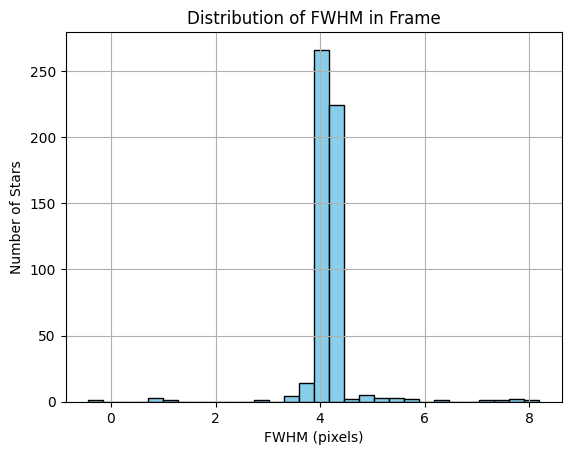

In [ ]:
import numpy as np
from astropy.io import fits
from photutils.detection import DAOStarFinder
from photutils.aperture import CircularAperture
from photutils.background import MMMBackground
from astropy.stats import mad_std
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import os


# --- 2D Gaussian model ---
def gaussian_2d(xy, amp, xo, yo, sigma_x, sigma_y, offset):
    x, y = xy
    xo = float(xo)
    yo = float(yo)
    g = offset + amp * np.exp(
        -(((x - xo) ** 2) / (2 * sigma_x**2) + ((y - yo) ** 2) / (2 * sigma_y**2))
    )
    return g.ravel()


In [6]:
# Path to your FITS file
current_dir = os.getcwd()  # Get the current working directory
file_path = os.path.join(current_dir, "HATS-38b", "lco_data-20250407-211")
fits_files = [f for f in os.listdir(file_path) if f.endswith(".fits.fz")]
file_name = [f for f in fits_files if '-0173-' in f][0]
file_test = os.path.join(file_path, file_name)

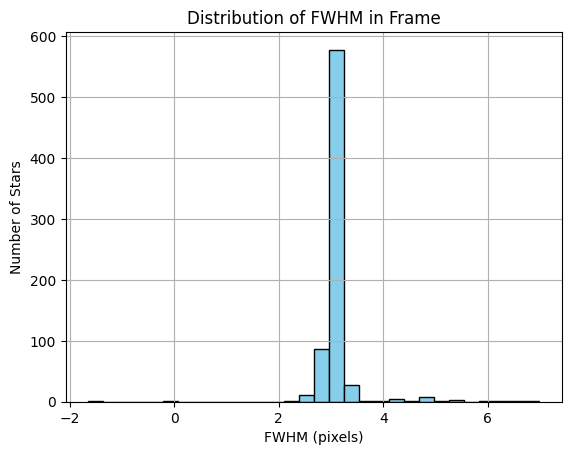

In [7]:

# --- Load the FITS frame ---
filename = file_test  # Replace with your filename
with fits.open(filename) as hdul:
    data = hdul['SCI'].data  # Adjust if your image is in a different HDU

# --- Estimate background and noise ---
bkg_estimator = MMMBackground()
bkg = bkg_estimator(data)
threshold = bkg + 5 * mad_std(data)

# --- Find stars ---
daofind = DAOStarFinder(fwhm=3.0, threshold=threshold)
sources = daofind(data - bkg)

# --- Extract FWHM from 2D Gaussian fits ---
fwhms = []
boxsize = 9  # size of cutout box around each star

for src in sources:
    x, y = src['xcentroid'], src['ycentroid']
    x = int(x)
    y = int(y)

    # Skip stars too close to edge
    if x < boxsize or y < boxsize or x+boxsize >= data.shape[1] or y+boxsize >= data.shape[0]:
        continue

    cutout = data[y - boxsize : y + boxsize, x - boxsize : x + boxsize]
    x_vals = np.arange(0, cutout.shape[1])
    y_vals = np.arange(0, cutout.shape[0])
    x_mesh, y_mesh = np.meshgrid(x_vals, y_vals)

    try:
        initial_guess = (
            cutout.max(), boxsize, boxsize, 2.0, 2.0, np.median(cutout)
        )
        popt, _ = curve_fit(
            gaussian_2d,
            (x_mesh, y_mesh),
            cutout.ravel(),
            p0=initial_guess
        )

        _, _, _, sigma_x, sigma_y, _ = popt
        fwhm = 2.355 * np.mean([sigma_x, sigma_y])  # convert sigma to FWHM
        fwhms.append(fwhm)
    except Exception:
        continue

# --- Plot histogram of FWHMs ---
plt.hist(fwhms, bins=30, color='skyblue', edgecolor='black')
plt.xlabel("FWHM (pixels)")
plt.ylabel("Number of Stars")
plt.title("Distribution of FWHM in Frame")
plt.grid(True)
plt.show()
